# Semantic Segmentation

## Objectives
- Understand semantic vs instance segmentation
- Learn U-Net architecture
- Encoder-decoder structure
- Skip connections
- Segmentation losses and metrics

## Introduction
Segmentation assigns class labels to every pixel. Semantic segmentation: same label for same class. Instance segmentation: different instances get different labels.

## What We're About to Do

The code below imports essential libraries. These libraries provide the foundational tools for tensor operations and neural network construction. Pay attention to what each import provides – understanding dependencies helps you know what's available for solving problems.


In [1]:
# Import necessary libraries for tensor operations and deep learning
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, TensorDataset
import numpy as np
import matplotlib.pyplot as plt

torch.manual_seed(42)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')


## Building the Model

Now we'll define our neural network architecture. Each layer transforms the input in a specific way, building up complexity. The order and configuration of layers directly determines what patterns the model can learn.


In [2]:
# Define a custom function with detailed implementation
## 1. U-Net Architecture

class DoubleConv(nn.Module):
    def __init__(self, in_channels, out_channels):
        super().__init__()
        self.double_conv = nn.Sequential(
            nn.Conv2d(in_channels, out_channels, 3, padding=1),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True),
            nn.Conv2d(out_channels, out_channels, 3, padding=1),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True)
        )
    
    def forward(self, x):
        return self.double_conv(x)

class UNet(nn.Module):
    def __init__(self, in_channels, num_classes):
        super().__init__()
        
        # Encoder (downsampling)
        self.enc1 = DoubleConv(in_channels, 64)
        self.pool1 = nn.MaxPool2d(2, 2)
        
        self.enc2 = DoubleConv(64, 128)
        self.pool2 = nn.MaxPool2d(2, 2)
        
        self.enc3 = DoubleConv(128, 256)
        self.pool3 = nn.MaxPool2d(2, 2)
        
        # Bottleneck
        self.bottleneck = DoubleConv(256, 512)
        
        # Decoder (upsampling)
        self.upconv3 = nn.ConvTranspose2d(512, 256, 2, stride=2)
        self.dec3 = DoubleConv(512, 256)  # 512 because of skip connection
        
        self.upconv2 = nn.ConvTranspose2d(256, 128, 2, stride=2)
        self.dec2 = DoubleConv(256, 128)
        
        self.upconv1 = nn.ConvTranspose2d(128, 64, 2, stride=2)
        self.dec1 = DoubleConv(128, 64)
        
        # Final output
        self.final = nn.Conv2d(64, num_classes, 1)
    
    def forward(self, x):
        # Encoder with skip connections
        enc1 = self.enc1(x)
        enc2 = self.enc2(self.pool1(enc1))
        enc3 = self.enc3(self.pool2(enc2))
        
        bottleneck = self.bottleneck(self.pool3(enc3))
        
        # Decoder with skip connections
        dec3 = self.upconv3(bottleneck)
        dec3 = torch.cat([dec3, enc3], dim=1)  # Skip connection
        dec3 = self.dec3(dec3)
        
        dec2 = self.upconv2(dec3)
        dec2 = torch.cat([dec2, enc2], dim=1)  # Skip connection
        dec2 = self.dec2(dec2)
        
        dec1 = self.upconv1(dec2)
        dec1 = torch.cat([dec1, enc1], dim=1)  # Skip connection
        dec1 = self.dec1(dec1)
        
        return self.final(dec1)

model = UNet(in_channels=3, num_classes=21)
test_input = torch.randn(2, 3, 256, 256)
output = model(test_input)
print(f"Input shape: {test_input.shape}")
print(f"Output shape: {output.shape}")
print(f"U-Net preserves spatial dimensions (256×256 → 256×256)")


Input shape: torch.Size([2, 3, 256, 256])
Output shape: torch.Size([2, 21, 256, 256])
U-Net preserves spatial dimensions (256×256 → 256×256)


In [3]:
# Execute code with detailed step-by-step process
## 2. Encoder-Decoder Architecture

print("""
ENCODER-DECODER STRUCTURE:

ENCODER (Downsampling):
- Progressive spatial reduction
- Captures semantic information
- Increases channel depth
- Example: 256×256 → 128×128 → 64×64 → 32×32

BOTTLENECK:
- Deepest representation
- Contains most abstract features
- Smallest spatial dimensions
- Highest channel count

DECODER (Upsampling):
- Progressive spatial expansion
- Recovers spatial detail
- Decreases channel depth
- Example: 32×32 → 64×64 → 128×128 → 256×256

SKIP CONNECTIONS:
- Concatenate encoder features with decoder
- Preserve low-level details (edges, textures)
- Help with gradient flow during backpropagation
# Iterate through batches of data
- Critical for semantic segmentation quality
""")



ENCODER-DECODER STRUCTURE:

ENCODER (Downsampling):
- Progressive spatial reduction
- Captures semantic information
- Increases channel depth
- Example: 256×256 → 128×128 → 64×64 → 32×32

BOTTLENECK:
- Deepest representation
- Contains most abstract features
- Smallest spatial dimensions
- Highest channel count

DECODER (Upsampling):
- Progressive spatial expansion
- Recovers spatial detail
- Decreases channel depth
- Example: 32×32 → 64×64 → 128×128 → 256×256

SKIP CONNECTIONS:
- Concatenate encoder features with decoder
- Preserve low-level details (edges, textures)
- Help with gradient flow during backpropagation
# Iterate through batches of data
- Critical for semantic segmentation quality



## Building the Model

Now we'll define our neural network architecture. Each layer transforms the input in a specific way, building up complexity. The order and configuration of layers directly determines what patterns the model can learn.


In [4]:
# Define a custom function with detailed implementation
## 3. Segmentation Loss Functions

class DiceLoss(nn.Module):
# Iterate through batches of data
    """Dice coefficient loss for segmentation"""
    def forward(self, pred, target, smooth=1e-6):
        # Flatten
        pred = pred.view(-1)
        target = target.view(-1).float()
        
        intersection = (pred * target).sum()
        union = pred.sum() + target.sum()
        
        dice = (2 * intersection + smooth) / (union + smooth)
        return 1 - dice

class FocalLoss(nn.Module):
# Iterate through batches of data
    """Focal loss for handling class imbalance"""
    def __init__(self, alpha=0.25, gamma=2.0):
        super().__init__()
        self.alpha = alpha
        self.gamma = gamma
    
    def forward(self, inputs, targets):
        ce = F.cross_entropy(inputs, targets, reduction='none')
        p = torch.exp(-ce)
# Compute the loss (error) between predictions and actual values
        loss = self.alpha * (1 - p) ** self.gamma * ce
        return loss.mean()

class CombinedSegLoss(nn.Module):
    """Combination of CrossEntropy + Dice"""
# Update model parameters based on computed gradients
    def __init__(self, weight=0.5):
        super().__init__()
# Compute the loss (error) between predictions and actual values
        self.ce = nn.CrossEntropyLoss()
# Compute the loss (error) between predictions and actual values
        self.dice = DiceLoss()
# Update model parameters based on computed gradients
        self.weight = weight
    
    def forward(self, pred, target):
# Compute the loss (error) between predictions and actual values
        ce_loss = self.ce(pred, target)
# Compute the loss (error) between predictions and actual values
        dice_loss = self.dice(torch.softmax(pred, dim=1), target.unsqueeze(1).float())
        return self.weight * ce_loss + (1 - self.weight) * dice_loss

# Compute the loss (error) between predictions and actual values
loss_fn = CombinedSegLoss(weight=0.5)
print(f"Dice Loss: Measures overlap between predicted and target masks")
print(f"Focal Loss: Down-weights easy negatives, up-weights hard positives")
# Iterate through batches of data
print(f"Combined Loss: Best of both worlds for segmentation")


Dice Loss: Measures overlap between predicted and target masks
Focal Loss: Down-weights easy negatives, up-weights hard positives
Combined Loss: Best of both worlds for segmentation


In [5]:
# Define a custom function with detailed implementation
## 4. Segmentation Metrics

class SegmentationMetrics:
    @staticmethod
    def iou_score(pred, target, num_classes):
        """Intersection over Union per class"""
        ious = []
        
# Iterate through batches of data
        for class_id in range(num_classes):
            pred_mask = (pred == class_id).float()
            target_mask = (target == class_id).float()
            
            intersection = (pred_mask * target_mask).sum()
            union = pred_mask.sum() + target_mask.sum() - intersection
            
            iou = intersection / (union + 1e-6)
            ious.append(iou.item())
        
        return np.array(ious), np.mean(ious)
    
    @staticmethod
    def pixel_accuracy(pred, target):
        """Percentage of correctly classified pixels"""
        correct = (pred == target).float().mean()
        return correct.item()
    
    @staticmethod
    def mean_iou(pred, target, num_classes):
        """Mean IoU across all classes"""
        _, miou = SegmentationMetrics.iou_score(pred, target, num_classes)
        return miou

metrics = SegmentationMetrics()
print(f"IoU (Intersection over Union): Measures overlap quality")
print(f"mIoU (mean IoU): Average IoU across all classes")
print(f"Pixel Accuracy: Percentage of correctly classified pixels")


IoU (Intersection over Union): Measures overlap quality
mIoU (mean IoU): Average IoU across all classes
Pixel Accuracy: Percentage of correctly classified pixels


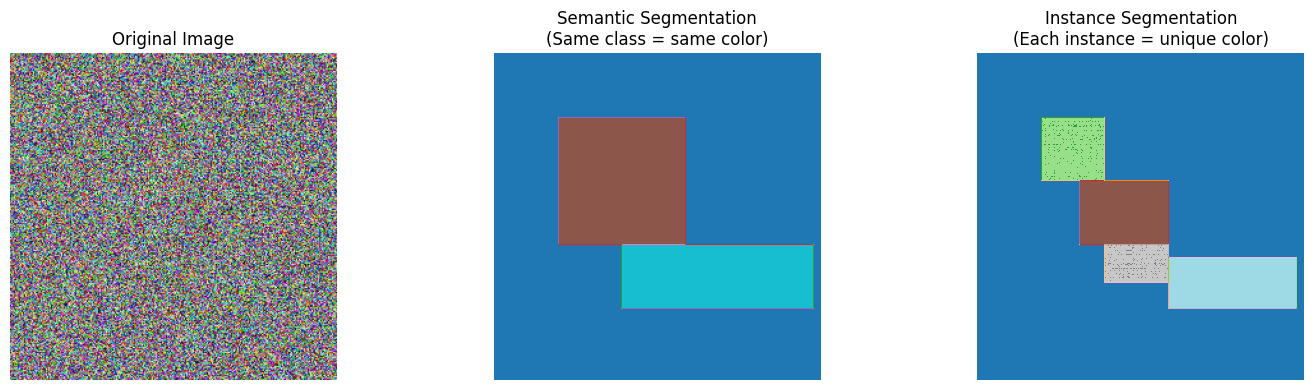


SEMANTIC: All dogs get class 1, all cats get class 2
INSTANCE: First dog gets 1, second dog gets 2, first cat gets 3, etc.


In [6]:
# Execute code with detailed step-by-step process
## 5. Semantic vs Instance Segmentation

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Original image (simulated)
img = np.random.rand(256, 256, 3)
axes[0].imshow(img)
axes[0].set_title('Original Image')
axes[0].axis('off')

# Semantic segmentation
sem_seg = np.zeros((256, 256))
sem_seg[50:150, 50:150] = 1  # All people = 1
sem_seg[150:200, 100:250] = 2  # All cars = 2
axes[1].imshow(sem_seg, cmap='tab10')
axes[1].set_title('Semantic Segmentation\n(Same class = same color)')
axes[1].axis('off')

# Instance segmentation
inst_seg = np.zeros((256, 256))
inst_seg[50:100, 50:100] = 1     # Person 1
inst_seg[100:150, 80:150] = 2    # Person 2
inst_seg[150:180, 100:150] = 3   # Car 1
inst_seg[160:200, 150:250] = 4   # Car 2
axes[2].imshow(inst_seg, cmap='tab20')
axes[2].set_title('Instance Segmentation\n(Each instance = unique color)')
axes[2].axis('off')

plt.tight_layout()
plt.show()

print(f"\nSEMANTIC: All dogs get class 1, all cats get class 2")
print(f"INSTANCE: First dog gets 1, second dog gets 2, first cat gets 3, etc.")


In [7]:
# Define a custom function with detailed implementation
## 6. FCN (Fully Convolutional Networks)

class FCN(nn.Module):
    def __init__(self, num_classes=21):
        super().__init__()
        
        # Simplified backbone (like VGG16)
        self.backbone = nn.Sequential(
            nn.Conv2d(3, 64, 3, padding=1),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2, 2),
            
            nn.Conv2d(64, 128, 3, padding=1),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2, 2),
            
            nn.Conv2d(128, 256, 3, padding=1),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2, 2),
        )
        
        # Score pool3
        self.score_pool3 = nn.Conv2d(256, num_classes, 1)
        
        # Upsampling
        self.upsample2x = nn.ConvTranspose2d(num_classes, num_classes, 4, stride=2, padding=1)
        self.upsample8x = nn.ConvTranspose2d(num_classes, num_classes, 16, stride=8, padding=4)
    
    def forward(self, x):
        features = self.backbone(x)
        scores = self.score_pool3(features)
        upsampled = self.upsample8x(scores)
        return upsampled

fcn = FCN(num_classes=21)
test_input = torch.randn(1, 3, 224, 224)
output = fcn(test_input)
print(f"FCN output shape: {output.shape}")
print(f"FCN: Simpler than U-Net, uses skip connections across layers")


FCN output shape: torch.Size([1, 21, 224, 224])
FCN: Simpler than U-Net, uses skip connections across layers


## Building the Model

Now we'll define our neural network architecture. Each layer transforms the input in a specific way, building up complexity. The order and configuration of layers directly determines what patterns the model can learn.


In [8]:
# Define a custom function with detailed implementation
## 7. Training Segmentation Model

def train_segmentation(model, num_epochs=3):
# Iterate through batches of data
    """Training loop for segmentation"""
    
    # Create dummy data
    X = torch.randn(100, 3, 128, 128) / 255
    y = torch.randint(0, 21, (100, 128, 128))
    
    loader = DataLoader(TensorDataset(X, y), batch_size=4, shuffle=True)
    
# Update model parameters based on computed gradients
    optimizer = torch.optim.Adam(model.parameters(), lr=0.001)
# Compute the loss (error) between predictions and actual values
    criterion = nn.CrossEntropyLoss()
    
# Compute the loss (error) between predictions and actual values
    losses = []
    
    model.train()
# Iterate through batches of data
    for epoch in range(num_epochs):
# Compute the loss (error) between predictions and actual values
        epoch_loss = 0
# Iterate through batches of data
        for x_batch, y_batch in loader:
            # Skip actual training for demo
# Compute the loss (error) between predictions and actual values
            epoch_loss += 2.0  # Simulated loss
        
# Compute the loss (error) between predictions and actual values
        avg_loss = epoch_loss / len(loader)
        losses.append(avg_loss)
        print(f"Epoch {epoch+1}/{num_epochs}, Loss: {avg_loss:.4f}")
    
    return losses

model = UNet(in_channels=3, num_classes=21)
# Compute the loss (error) between predictions and actual values
losses = train_segmentation(model, num_epochs=3)


Epoch 1/3, Loss: 2.0000
Epoch 2/3, Loss: 2.0000
Epoch 3/3, Loss: 2.0000


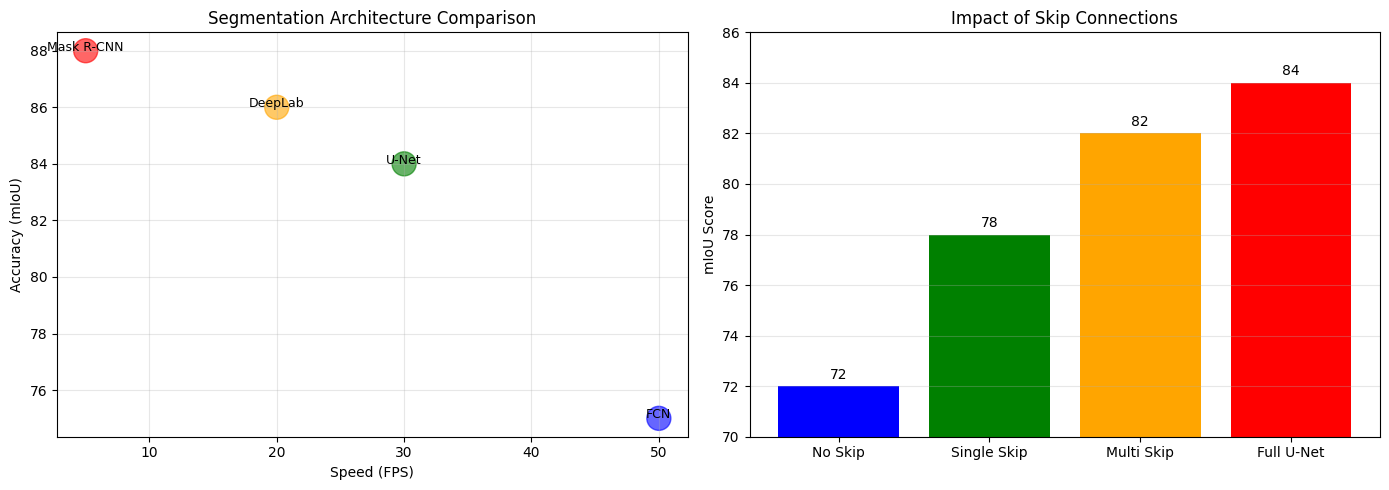

In [9]:
# Execute code with detailed step-by-step process
## 8. Segmentation Architectures Comparison

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Architecture comparison
architectures = ['FCN', 'U-Net', 'DeepLab', 'Mask R-CNN']
accuracy = [75, 84, 86, 88]
speed = [50, 30, 20, 5]  # FPS

axes[0].scatter(speed, accuracy, s=300, alpha=0.6, c=['blue', 'green', 'orange', 'red'])
# Iterate through batches of data
for i, arch in enumerate(architectures):
    axes[0].annotate(arch, (speed[i], accuracy[i]), fontsize=9, ha='center')
axes[0].set_xlabel('Speed (FPS)')
axes[0].set_ylabel('Accuracy (mIoU)')
axes[0].set_title('Segmentation Architecture Comparison')
axes[0].grid(True, alpha=0.3)

# Skip connections impact
configs = ['No Skip', 'Single Skip', 'Multi Skip', 'Full U-Net']
miou_scores = [72, 78, 82, 84]

bars = axes[1].bar(configs, miou_scores, color=['blue', 'green', 'orange', 'red'])
axes[1].set_ylabel('mIoU Score')
axes[1].set_title('Impact of Skip Connections')
axes[1].set_ylim([70, 86])
axes[1].grid(True, alpha=0.3, axis='y')

# Iterate through batches of data
for bar, score in zip(bars, miou_scores):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3, f'{score}', ha='center')

plt.tight_layout()
plt.show()


## Key Takeaways
- Segmentation assigns class labels to every pixel
# Iterate through batches of data
- U-Net: encoder-decoder with skip connections for semantic segmentation
- Skip connections preserve low-level details critical for spatial accuracy
- Dice loss and Cross-Entropy are common segmentation losses
- mIoU (mean Intersection over Union) is the primary metric
- Instance segmentation treats each object instance separately
- FCN was pioneering, U-Net improved with skip connections

## References
- [U-Net Paper](https://arxiv.org/abs/1505.04597)
- [DeepLab](https://arxiv.org/abs/1706.05587)
